In [23]:
# In this notebook will be showed the image data wich will be 
# used to the training of the models 

import os

# Resolve paths relative to the project root (parent of this notebooks/ folder),
# so this works regardless of Jupyter's working directory.
PROJECT_ROOT = os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()) == "notebooks" else os.getcwd()

COCO_ROOT = os.path.join(PROJECT_ROOT, "data", "raw", "CarDD_release", "CarDD_release", "CarDD_COCO")

train_path = os.path.join(COCO_ROOT, "train2017")
test_path = os.path.join(COCO_ROOT, "test2017")
val_path = os.path.join(COCO_ROOT, "val2017")

train_ann_path = os.path.join(COCO_ROOT, "annotations", "instances_train2017.json")
test_ann_path = os.path.join(COCO_ROOT, "annotations", "instances_test2017.json")
val_ann_path = os.path.join(COCO_ROOT, "annotations", "instances_val2017.json")

In [24]:
import json
from collections import defaultdict

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import glob

def load_coco_annotations(ann_json_path):
    with open(ann_json_path, "r") as f:
        data = json.load(f)

    categories = {c["id"]: c["name"] for c in data["categories"]}
    image_id_by_filename = {img["file_name"]: img["id"] for img in data["images"]}

    anns_by_image_id = defaultdict(list)
    for ann in data["annotations"]:
        anns_by_image_id[ann["image_id"]].append(ann)

    cmap = matplotlib.colormaps["tab20"].resampled(max(len(categories), 1))
    category_colors = {cid: cmap(i % 20) for i, cid in enumerate(sorted(categories))}

    return image_id_by_filename, anns_by_image_id, categories, category_colors

def draw_annotations(ax, anns, categories, category_colors, show_bbox=True, show_segmentation=True):
    for ann in anns:
        color = category_colors[ann["category_id"]]
        label = categories.get(ann["category_id"], str(ann["category_id"]))

        if show_segmentation and isinstance(ann.get("segmentation"), list):
            for seg in ann["segmentation"]:
                if len(seg) >= 6:
                    poly_pts = np.array(seg).reshape(-1, 2)
                    ax.add_patch(plt.Polygon(poly_pts, closed=True, edgecolor=color,
                                              facecolor=color, alpha=0.25, linewidth=1.2))

        if show_bbox and ann.get("bbox"):
            x, y, w, h = ann["bbox"]
            ax.add_patch(plt.Rectangle((x, y), w, h, edgecolor=color, facecolor="none", linewidth=1.5))
            ax.text(x, max(y - 3, 0), label, fontsize=6, color="white",
                    bbox=dict(facecolor=color, alpha=0.8, pad=1, edgecolor="none"))

def show_samples(folder_path, title, ann_json_path=None, n=10, cols=5, show_bbox=True, show_segmentation=True):
    image_files = sorted(glob.glob(os.path.join(folder_path, "*.jpg"))) + \
                  sorted(glob.glob(os.path.join(folder_path, "*.png")))

    num_images = min(n, len(image_files))
    rows = (num_images + cols - 1) // cols if num_images else 1
    fig, axes = plt.subplots(rows, cols, figsize=(3 * cols, 3 * rows))
    axes = axes.flatten()

    image_id_by_filename, anns_by_image_id, categories, category_colors = {}, {}, {}, {}
    if ann_json_path:
        image_id_by_filename, anns_by_image_id, categories, category_colors = load_coco_annotations(ann_json_path)

    legend_categories = {}
    total_anns_shown = 0

    for idx in range(num_images):
        fname = os.path.basename(image_files[idx])
        img = Image.open(image_files[idx])
        ax = axes[idx]
        ax.imshow(img)
        ax.set_title(fname, fontsize=8)
        ax.axis('off')

        if ann_json_path:
            image_id = image_id_by_filename.get(fname)
            anns = anns_by_image_id.get(image_id, []) if image_id is not None else []
            draw_annotations(ax, anns, categories, category_colors, show_bbox, show_segmentation)
            total_anns_shown += len(anns)
            for ann in anns:
                legend_categories[ann["category_id"]] = category_colors[ann["category_id"]]

    for idx in range(num_images, len(axes)):
        axes[idx].axis('off')

    if legend_categories:
        handles = [plt.Line2D([0], [0], marker='s', color='w', markerfacecolor=color, markersize=10,
                               label=categories[cid])
                   for cid, color in sorted(legend_categories.items())]
        fig.legend(handles=handles, loc='lower center', ncol=min(len(handles), 6), fontsize=8,
                   bbox_to_anchor=(0.5, -0.03))

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

    print(f"Displayed {num_images} of {len(image_files)} images from {folder_path}")
    if ann_json_path:
        print(f"Showing {total_anns_shown} annotation(s) across these images")

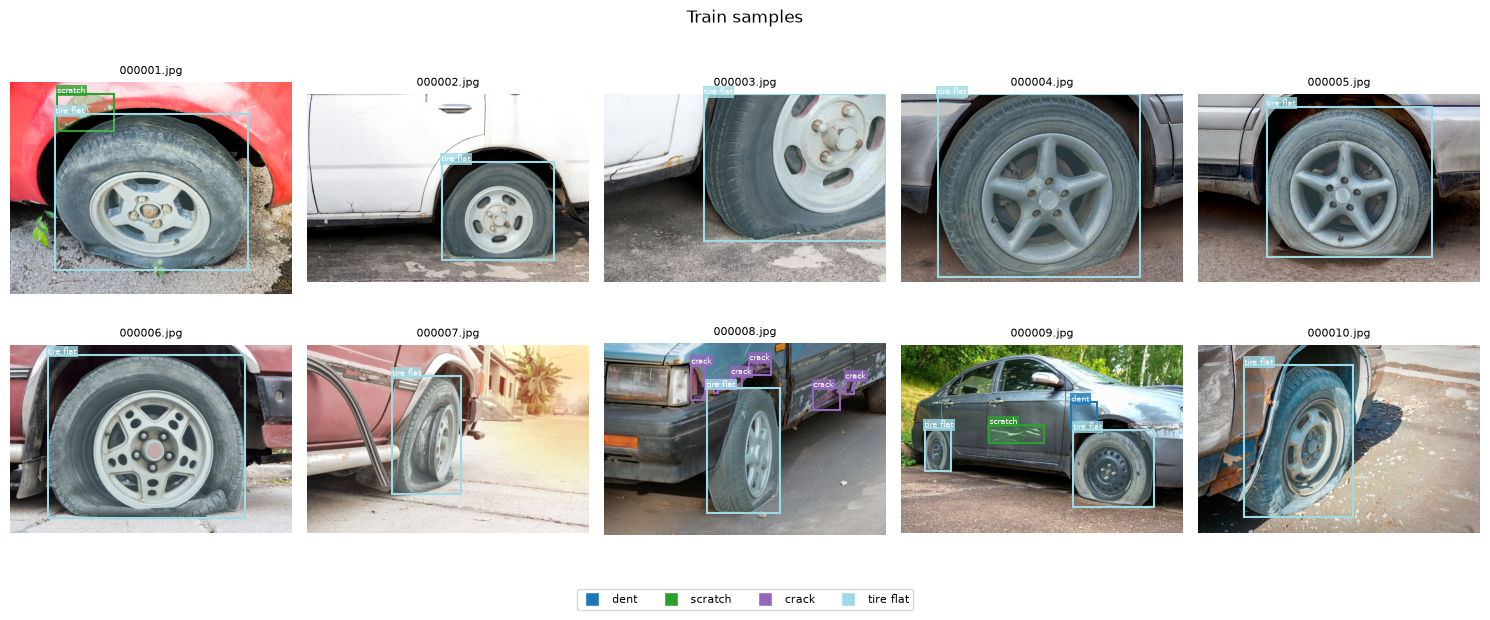

Displayed 10 of 2816 images from c:\Users\barucroj\Desktop\IPN\TTR\Code\prototipo-deteccion-danos\data\raw\CarDD_release\CarDD_release\CarDD_COCO\train2017
Showing 20 annotation(s) across these images


In [25]:
show_samples(train_path, "Train samples", ann_json_path=train_ann_path)

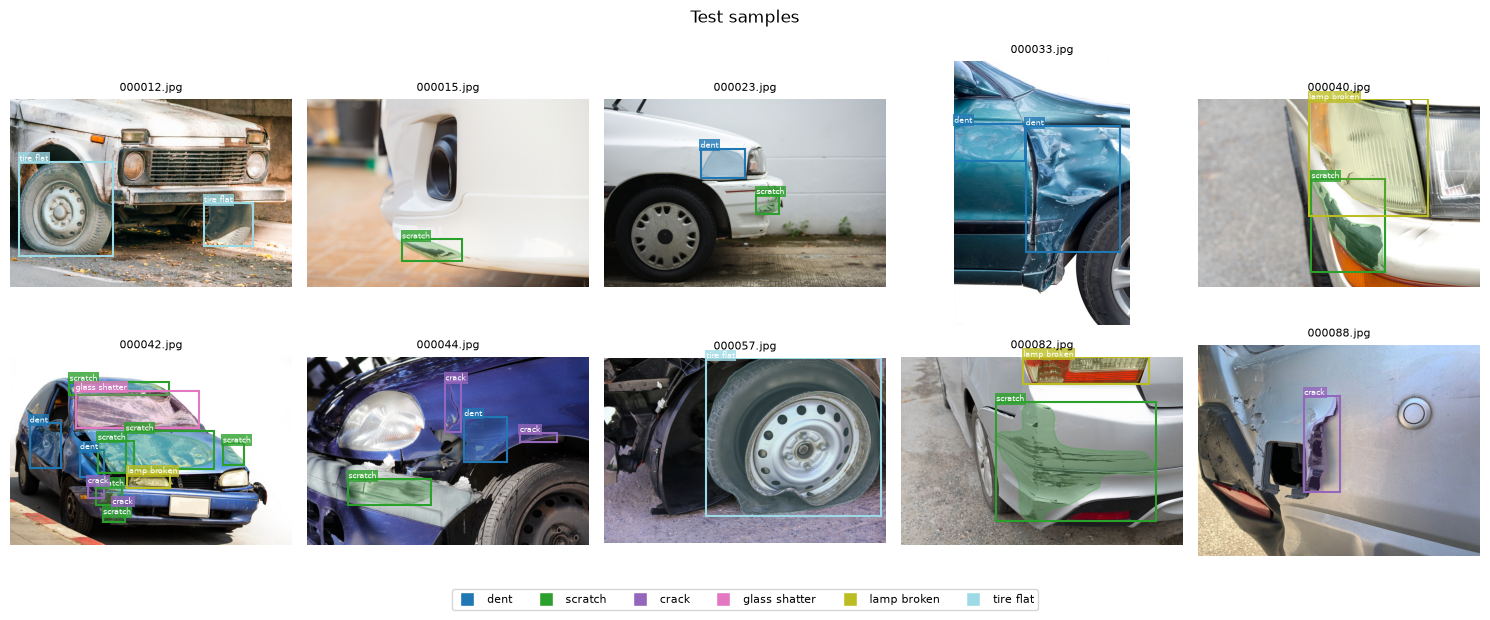

Displayed 10 of 374 images from c:\Users\barucroj\Desktop\IPN\TTR\Code\prototipo-deteccion-danos\data\raw\CarDD_release\CarDD_release\CarDD_COCO\test2017
Showing 29 annotation(s) across these images


In [26]:
show_samples(test_path, "Test samples", ann_json_path=test_ann_path)

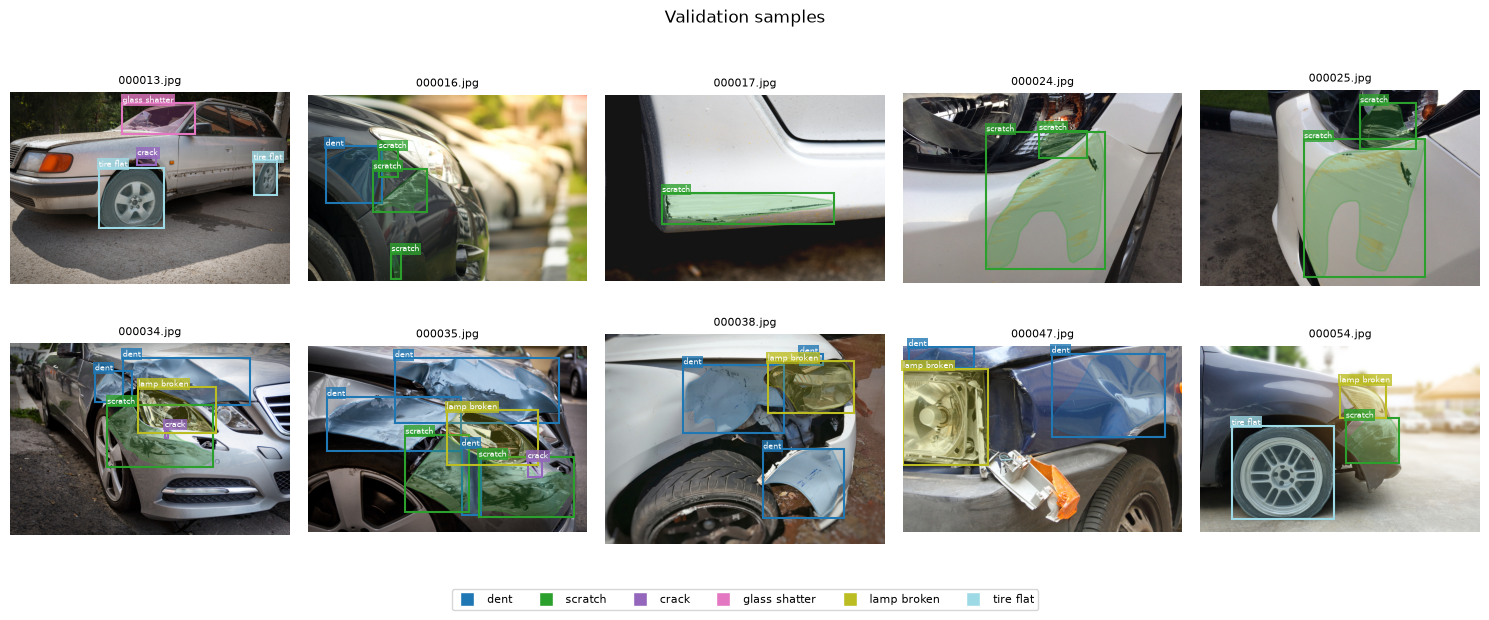

Displayed 10 of 810 images from c:\Users\barucroj\Desktop\IPN\TTR\Code\prototipo-deteccion-danos\data\raw\CarDD_release\CarDD_release\CarDD_COCO\val2017
Showing 35 annotation(s) across these images


In [27]:
show_samples(val_path, "Validation samples", ann_json_path=val_ann_path)